In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="black">ch3. RNN(Recurrent Neural Network ; 순환신경망)</font>
- 순서와 맥락이 중요한 데이터를 처리하기 위해 고안된 인공 신경망 구조 
    * ex) 번역, 음성 인식, 주가 예측, 단어 예측 등
    
# 1. 다음 단어 예측 모델 구현

* pad_sequences()
    * maxlen : 모델 입력 크기를 규격화하기 위한 문장(시퀀스)의 최대 길이 지정 옵션
    * padding='pre' : 시퀀스 앞쪽에 `0`을 채워 넣는 기본 옵션 (RNN 계열 모델의 장기 의존성 유지에 유리)
    * padding='post' : 시퀀스 뒤쪽에 `0`을 채워 넣는 패딩 위치 설정 옵션
    * truncating='pre' : `maxlen` 초과 시 시퀀스의 앞쪽 단어들을 자르는 손실 처리 기본 옵션
    * truncating='post' : `maxlen` 초과 시 시퀀스의 뒤쪽 단어들을 자르는 손실 처리 옵션
    * value : 패딩 시 기본값 `0` 대신 입력할 특정 지정 값 설정 옵션
    * dtype : 패딩 처리 후 반환되는 넘파이 배열(Numpy Array)의 데이터 타입 지정 옵션
* Tokenizer.texts_to_sequences() : 텍스트 문장을 정수 인덱스 시퀀스 리스트로 1차 변환하는 전처리 과정

In [3]:
text = '''
경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고와야 오는 말이 곱다'''
text1 = '겨울이 오는 날'

In [5]:
from keras_preprocessing.text import Tokenizer
token = Tokenizer()
token.fit_on_texts([text, text1])
encoded = token.texts_to_sequences([text, text1])
print(encoded)
print(token.word_index)

[[3, 4, 1, 5, 6, 7, 1, 8, 9, 1, 10, 2, 1, 11], [12, 2, 13]]
{'말이': 1, '오는': 2, '경마장에': 3, '있는': 4, '뛰고': 5, '있다': 6, '그의': 7, '법이다': 8, '가는': 9, '고와야': 10, '곱다': 11, '겨울이': 12, '날': 13}


In [6]:
text = '''
경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고와야 오는 말이 곱다'''

In [7]:
# 등장 빈도가 높은 순서대로 단어마다 인덱스를 매겨 Dict 형태로 출력
token = Tokenizer()
token.fit_on_texts([text])
print(token.word_index)

[[2, 3, 1, 4, 5, 6, 1, 7, 8, 1, 9, 10, 1, 11]]
{'말이': 1, '경마장에': 2, '있는': 3, '뛰고': 4, '있다': 5, '그의': 6, '법이다': 7, '가는': 8, '고와야': 9, '오는': 10, '곱다': 11}


In [8]:
# 입력받은 텍스트(문장)를 정수 숫자 리스트로 변환
encoded = token.texts_to_sequences([text])
print(encoded)

[[2, 3, 1, 4, 5, 6, 1, 7, 8, 1, 9, 10, 1, 11]]


In [9]:
for key, value in token.word_index.items():
    print(key, value)

말이 1
경마장에 2
있는 3
뛰고 4
있다 5
그의 6
법이다 7
가는 8
고와야 9
오는 10
곱다 11


In [15]:
# text를 학습시키기 위한
sequences = []
for line in text.split('\n'):
    print('원본 :', line)
    encoded = token.texts_to_sequences([line])[0]
    print('인코딩된 문장 :', encoded)
    for i in range(0, len(encoded)-1):
        for j in range(i+2, len(encoded)+1):
            sequences.append(encoded[i:j])

print()
print('sequences와 해석 출력')
for sequence in sequences:
    for word_seq in sequence:
        for key, value in token.word_index.items():
            if word_seq==value:
                print(f'{word_seq}:{key}', end=' ')
                break
    print()

원본 : 
인코딩된 문장 : []
원본 : 경마장에 있는 말이 뛰고 있다
인코딩된 문장 : [2, 3, 1, 4, 5]
원본 : 그의 말이 법이다
인코딩된 문장 : [6, 1, 7]
원본 : 가는 말이 고와야 오는 말이 곱다
인코딩된 문장 : [8, 1, 9, 10, 1, 11]

sequences와 해석 출력
2:경마장에 3:있는 
2:경마장에 3:있는 1:말이 
2:경마장에 3:있는 1:말이 4:뛰고 
2:경마장에 3:있는 1:말이 4:뛰고 5:있다 
3:있는 1:말이 
3:있는 1:말이 4:뛰고 
3:있는 1:말이 4:뛰고 5:있다 
1:말이 4:뛰고 
1:말이 4:뛰고 5:있다 
4:뛰고 5:있다 
6:그의 1:말이 
6:그의 1:말이 7:법이다 
1:말이 7:법이다 
8:가는 1:말이 
8:가는 1:말이 9:고와야 
8:가는 1:말이 9:고와야 10:오는 
8:가는 1:말이 9:고와야 10:오는 1:말이 
8:가는 1:말이 9:고와야 10:오는 1:말이 11:곱다 
1:말이 9:고와야 
1:말이 9:고와야 10:오는 
1:말이 9:고와야 10:오는 1:말이 
1:말이 9:고와야 10:오는 1:말이 11:곱다 
9:고와야 10:오는 
9:고와야 10:오는 1:말이 
9:고와야 10:오는 1:말이 11:곱다 
10:오는 1:말이 
10:오는 1:말이 11:곱다 
1:말이 11:곱다 


In [19]:
# sequences의 길이를 일정하게 맞추기(padding)
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences = pad_sequences(sequences) # 2차원 리스트 입력

In [21]:
padded_sequences[:3]

array([[0, 0, 0, 0, 2, 3],
       [0, 0, 0, 2, 3, 1],
       [0, 0, 2, 3, 1, 4]])

In [24]:
# 독립 변수와 타겟 변수 분리
X = padded_sequences[:,:-1]
y = padded_sequences[:,-1]

# 단어 개수
vocab_size = len(token.word_index)
vocab_size

11

In [26]:
# 종속 변수 원-핫 인코딩
from tensorflow.keras.utils import to_categorical
Y = to_categorical(y, vocab_size+1) # 0번 인덱스 포함을 위해 +1

- Embedding() : 정수 인덱스 $k$가 들어오면 메모리 주소 직접 참조(Look-up Table)를 통해 가중치 행렬 $W$의 $k$번째 행을 즉시 반환
    - 개념/수학적 측면: 정수 입력 $\rightarrow$ (원-핫 인코딩과 동일한 효과) $\rightarrow$ 해당 가중치 추출
    - 실제 연산 측면: 정수 입력 $\rightarrow$ 원-핫 생성 없이 메모리 인덱스 직행 참조(Look-up) $\rightarrow$ 해당 가중치 추출

In [27]:
# 모델 생성 (embedding → RNN → Dense)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential(name='sequential')

model.add(Embedding(input_dim=vocab_size+1, # 임베딩 입력 (독립 변수 원-핫 인코딩 처리)
                    output_dim=8, # 임베딩 출력
                    input_length=X.shape[1] # 독립 변수 길이
                   ))
model.add(SimpleRNN(32, activation='tanh'))
model.add(Dense(12, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 5, 8)              96        
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                1312      
                                                                 
 dense (Dense)               (None, 12)                396       
                                                                 
Total params: 1,804
Trainable params: 1,804
Non-trainable params: 0
_________________________________________________________________


In [28]:
# 학습과정 설정
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 학습
hist = model.fit(X, Y, epochs=300, verbose=2)

Epoch 1/300
1/1 - 1s - loss: 2.4924 - accuracy: 0.0714 - 1s/epoch - 1s/step
Epoch 2/300
1/1 - 0s - loss: 2.4790 - accuracy: 0.0714 - 8ms/epoch - 8ms/step
Epoch 3/300
1/1 - 0s - loss: 2.4660 - accuracy: 0.1786 - 6ms/epoch - 6ms/step
Epoch 4/300
1/1 - 0s - loss: 2.4533 - accuracy: 0.2857 - 0s/epoch - 0s/step
Epoch 5/300
1/1 - 0s - loss: 2.4407 - accuracy: 0.3214 - 4ms/epoch - 4ms/step
Epoch 6/300
1/1 - 0s - loss: 2.4281 - accuracy: 0.3214 - 14ms/epoch - 14ms/step
Epoch 7/300
1/1 - 0s - loss: 2.4153 - accuracy: 0.3214 - 0s/epoch - 0s/step
Epoch 8/300
1/1 - 0s - loss: 2.4021 - accuracy: 0.3214 - 16ms/epoch - 16ms/step
Epoch 9/300
1/1 - 0s - loss: 2.3885 - accuracy: 0.3214 - 0s/epoch - 0s/step
Epoch 10/300
1/1 - 0s - loss: 2.3743 - accuracy: 0.3214 - 2ms/epoch - 2ms/step
Epoch 11/300
1/1 - 0s - loss: 2.3594 - accuracy: 0.3214 - 13ms/epoch - 13ms/step
Epoch 12/300
1/1 - 0s - loss: 2.3437 - accuracy: 0.3214 - 0s/epoch - 0s/step
Epoch 13/300
1/1 - 0s - loss: 2.3272 - accuracy: 0.2857 - 14ms/ep

Epoch 106/300
1/1 - 0s - loss: 1.1088 - accuracy: 0.6429 - 0s/epoch - 0s/step
Epoch 107/300
1/1 - 0s - loss: 1.0968 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 108/300
1/1 - 0s - loss: 1.0851 - accuracy: 0.7143 - 808us/epoch - 808us/step
Epoch 109/300
1/1 - 0s - loss: 1.0736 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 110/300
1/1 - 0s - loss: 1.0624 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 111/300
1/1 - 0s - loss: 1.0514 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 112/300
1/1 - 0s - loss: 1.0407 - accuracy: 0.7143 - 3ms/epoch - 3ms/step
Epoch 113/300
1/1 - 0s - loss: 1.0302 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 114/300
1/1 - 0s - loss: 1.0199 - accuracy: 0.7143 - 16ms/epoch - 16ms/step
Epoch 115/300
1/1 - 0s - loss: 1.0099 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 116/300
1/1 - 0s - loss: 1.0000 - accuracy: 0.7143 - 15ms/epoch - 15ms/step
Epoch 117/300
1/1 - 0s - loss: 0.9904 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 118/300
1/1 - 0s - loss: 0.9810 - accura

Epoch 209/300
1/1 - 0s - loss: 0.5234 - accuracy: 0.8571 - 3ms/epoch - 3ms/step
Epoch 210/300
1/1 - 0s - loss: 0.5202 - accuracy: 0.8571 - 11ms/epoch - 11ms/step
Epoch 211/300
1/1 - 0s - loss: 0.5171 - accuracy: 0.8571 - 0s/epoch - 0s/step
Epoch 212/300
1/1 - 0s - loss: 0.5140 - accuracy: 0.8571 - 0s/epoch - 0s/step
Epoch 213/300
1/1 - 0s - loss: 0.5110 - accuracy: 0.8571 - 2ms/epoch - 2ms/step
Epoch 214/300
1/1 - 0s - loss: 0.5079 - accuracy: 0.8571 - 0s/epoch - 0s/step
Epoch 215/300
1/1 - 0s - loss: 0.5049 - accuracy: 0.8571 - 16ms/epoch - 16ms/step
Epoch 216/300
1/1 - 0s - loss: 0.5019 - accuracy: 0.8571 - 0s/epoch - 0s/step
Epoch 217/300
1/1 - 0s - loss: 0.4989 - accuracy: 0.8571 - 0s/epoch - 0s/step
Epoch 218/300
1/1 - 0s - loss: 0.4960 - accuracy: 0.8571 - 0s/epoch - 0s/step
Epoch 219/300
1/1 - 0s - loss: 0.4931 - accuracy: 0.8571 - 0s/epoch - 0s/step
Epoch 220/300
1/1 - 0s - loss: 0.4902 - accuracy: 0.8571 - 17ms/epoch - 17ms/step
Epoch 221/300
1/1 - 0s - loss: 0.4873 - accuracy

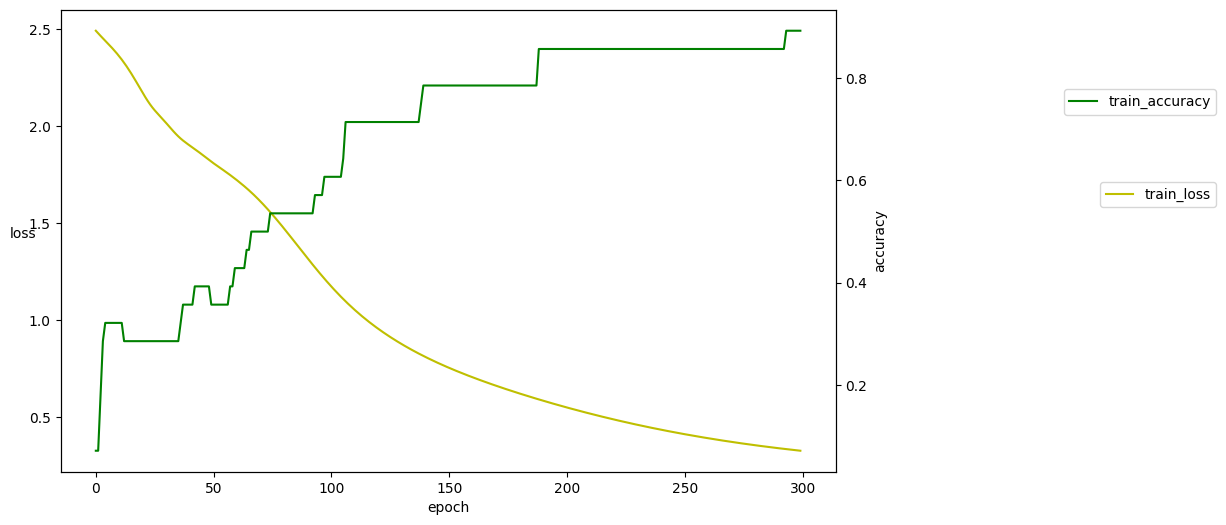

In [31]:
# 모델 평가
from matplotlib import pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.6), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.8), ncol=1)
plt.show()

In [49]:
# 모델 사용
encoded = token.texts_to_sequences(['말이'])[0]
input_data = pad_sequences([encoded], maxlen=5, padding='pre')

result = model.predict(input_data, verbose=0).argmax(axis=1)[0]

print('모델 예측 결과 :', result)

for key, value in token.word_index.items():
    if value == result:
        print('예측 단어 : ', key)
        break

모델 예측 결과 : 9
예측 단어 :  고와야


# 2. 이어질 문맥 예측 모델 구현

In [50]:
# '가는 말이' 이후에 올 단어 4개 예측
def sentence_generater(model, t, current_word, n):
    print('입력된 단어 :', current_word)
    for i in range(1, n+1):
        encoded = t.texts_to_sequences([current_word])[0]
        input_data = pad_sequences([encoded], maxlen=5, padding='pre')
        result = model.predict(input_data, verbose=0).argmax(axis=1)[0]
        for key, value in token.word_index.items():
            if value == result:
                print(f'{i}번째, {key}:{result}')
                current_word = current_word + " " + key
                break
    return current_word

In [51]:
sentence_generater(model, token, '가는 말이', 4)

입력된 단어 : 가는 말이
1번째, 고와야:9
2번째, 오는:10
3번째, 말이:1
4번째, 곱다:11


'가는 말이 고와야 오는 말이 곱다'